# RAG Agent Evaluation

This notebook demonstrates how to evaluate a Retrieval-Augmented Generation (RAG) agent using both retrieval-level and answer-level metrics.

The evaluation pipeline consists of two major parts:

1. **Retrieval Evaluation**
   - Measures how effectively the retriever returns relevant documents.
   - Uses ranking and coverage metrics such as:
     - Mean Reciprocal Rank (MRR)
     - Normalized Discounted Cumulative Gain (nDCG)
     - Keyword Coverage

2. **Answer Evaluation**
   - Measures the quality of the generated responses from the agent.
   - Uses an LLM-based judge model to evaluate:
     - Accuracy
     - Completeness
     - Relevance

The notebook initializes the full application context through the project bootstrap mechanism, executes evaluation suites asynchronously, and visualizes the resulting metrics.

## Environment Setup

This section initializes the project environment and loads the application context.

The notebook uses asynchronous execution because both retrieval and answer evaluation are performed concurrently.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.bootstrap import bootstrap

app_context = await bootstrap()

retriever = app_context.retriever
settings = app_context.settings
evaluator = app_context.evaluator
orchestrator = app_context.orchestrator

### Load Evaluation Dataset

The evaluator loads a predefined set of test cases from a JSON file.

Each test case may contain:
- User question
- Expected keywords for retrieval evaluation
- Reference answer for answer evaluation
- Optional conversation history
- Category label

These test cases are later used for both retrieval and generation benchmarks.

In [17]:
tests_path = settings["app"]["evaluation"]["test_file"]

evaluator.load_tests()

Loaded 40 tests into RAGEvaluator


### Retrieval Evaluation

This section evaluates the retriever independently from the generation pipeline.

For every test question, the evaluator:
1. Retrieves documents asynchronously
2. Computes ranking-based metrics
3. Measures keyword coverage inside retrieved documents

#### Metrics

`Mean Reciprocal Rank (MRR)`

Measures how early a relevant document appears in the ranking.
Higher values indicate that relevant documents are retrieved closer to the top.

`Normalized Discounted Cumulative Gain (nDCG)`

Evaluates ranking quality while considering the position of relevant documents.
Higher values indicate better ranking quality.

`Keyword Coverage`

Measures how many expected keywords were found across retrieved documents.
Expressed as a percentage.

In [ ]:
result_retrieval_tests = await evaluator.start_retrieval_tests(
    retriever=retriever,
    max_concurrency=13,
)

result_retrieval_tests = pd.DataFrame(result_retrieval_tests)

result_retrieval_tests.head()

### Retrieval Metrics Visualization
The following visualization aggregates retrieval metrics by category.

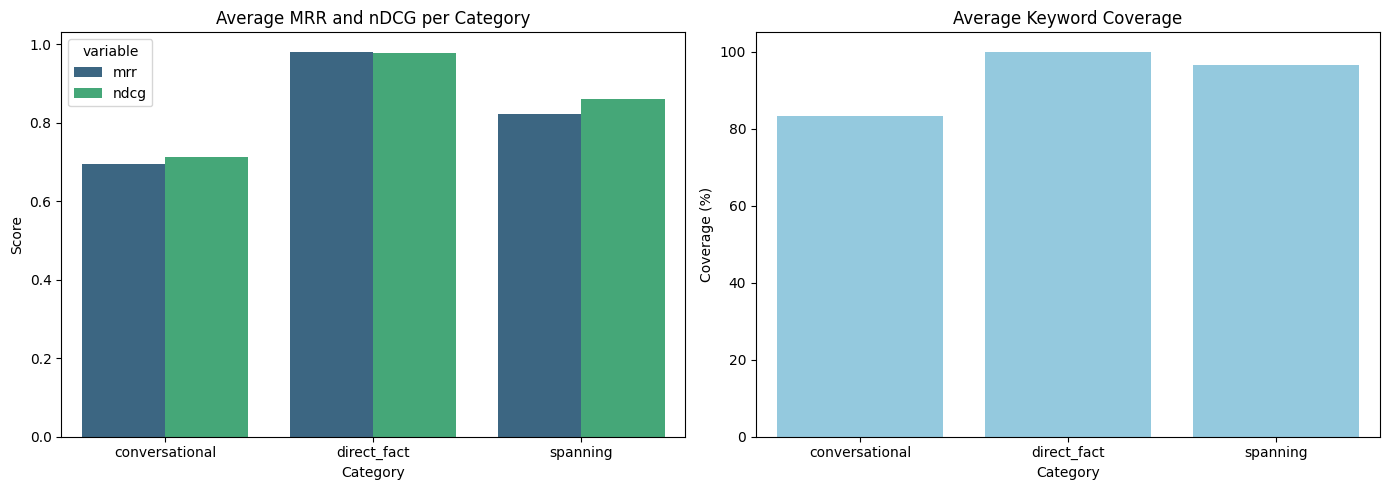

In [26]:
def plot_retrieval_metrics(results: list[dict]):
    """
    Visualize retrieval evaluation metrics grouped by category.

    Parameters
    ----------
    results : list of dict
        A collection of evaluation outcomes where each dictionary contains 
        at least the following keys: 'category', 'mrr', 'ndcg', 
        and 'keyword_coverage'.

    Returns
    -------
    None
        The function renders a Matplotlib figure directly.
    """
    # Convert input data to a DataFrame for efficient grouping and melting
    df = pd.DataFrame(results)

    # Compute mean performance metrics aggregated by category
    category_stats = (
        df.groupby("category")[["mrr", "ndcg", "keyword_coverage"]]
        .mean()
        .reset_index()
    )

    # Initialize a figure with two subplots for comparative analysis
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot MRR and nDCG on the first axis using a long-form transformation
    sns.barplot(
        data=category_stats.melt(
            id_vars="category",
            value_vars=["mrr", "ndcg"],
        ),
        x="category",
        y="value",
        hue="variable",
        palette="viridis",
        ax=axes[0],
    )

    # Configure aesthetics for the rank-based metrics chart
    axes[0].set_title("Average MRR and nDCG per Category")
    axes[0].set_xlabel("Category")
    axes[0].set_ylabel("Score")

    # Plot keyword coverage on the second axis to assess retrieval breadth
    sns.barplot(
        data=category_stats,
        x="category",
        y="keyword_coverage",
        color="skyblue",
        ax=axes[1],
    )

    # Configure aesthetics for the keyword coverage chart
    axes[1].set_title("Average Keyword Coverage")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Coverage (%)")

    # Finalize layout to prevent label overlapping and render the plot
    plt.tight_layout()
    plt.show()


# Execute the visualization for retrieval test results
plot_retrieval_metrics(result_retrieval_tests)

### Answer Evaluation

This section evaluates the final responses generated by the RAG agent.

The evaluation pipeline:
1. Runs the orchestrator
2. Generates answers for each test question
3. Sends generated and reference answers to an LLM-based judge
4. Produces structured evaluation scores

### Evaluation Criteria

`Accuracy`

Measures factual correctness compared to the reference answer.

`Completeness`

Measures whether the generated answer covers all important information.

`Relevance`

Measures how well the response addresses the user question.

In [20]:
initial_state = {
    "question": "",
    "messages": [],
    "documents": [],
    "answer": "",
    "user": {
        "user_id": "5",
    },
}

In [ ]:
result_answer_tests = await evaluator.start_answer_tests(
    orchestrator=orchestrator,
    base_state=initial_state,
    max_concurrency=13,
)

result_answer_tests = pd.DataFrame(result_answer_tests)

result_answer_tests.head()

### Answer Evaluation Visualization

The following charts visualize answer quality metrics produced by the judge model.

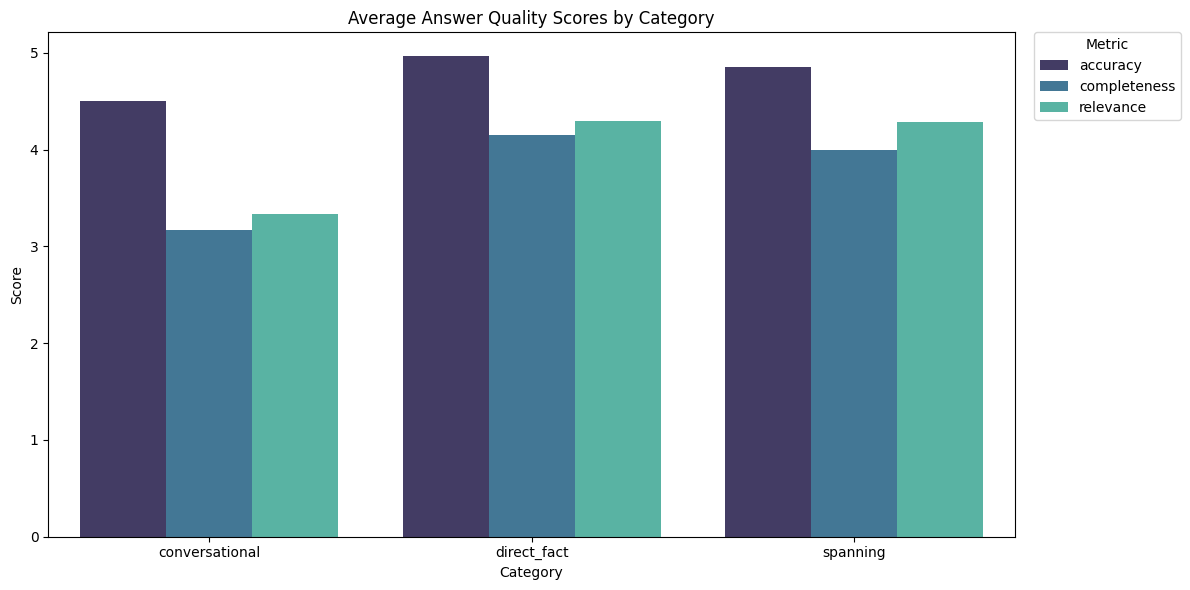

In [27]:
def plot_answer_metrics(results: list[dict]) -> None:
    """
    Visualize answer evaluation metrics grouped by category.

    Parameters
    ----------
    results : list of dict
        A collection of evaluation results. Each dictionary must contain 
        'status', 'category', 'accuracy', 'completeness', and 'relevance' keys.
    """
    # Create a DataFrame and filter for successful operations only
    df = pd.DataFrame(results)
    successful_results = df[df["status"] == "success"].copy()

    # Define the primary quality dimensions for evaluation
    metrics = ["accuracy", "completeness", "relevance"]

    # Calculate the mean value for each metric aggregated by category
    category_stats = (
        successful_results.groupby("category")[metrics]
        .mean()
        .reset_index()
    )

    # Initialize the plot figure with specific dimensions
    plt.figure(figsize=(12, 6))

    # Transform data to long-form and generate a grouped bar chart
    ax = sns.barplot(
        data=category_stats.melt(
            id_vars="category",
            value_vars=metrics,
        ),
        x="category",
        y="value",
        hue="variable",
        palette="mako",
    )

    # Configure plot labels and title for professional clarity
    ax.set_title("Average Answer Quality Scores by Category")
    ax.set_xlabel("Category")
    ax.set_ylabel("Score")

    # Position the legend outside the primary axes for better readability
    ax.legend(
        title="Metric",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
    )

    # Adjust layout to accommodate external legend and display the figure
    plt.tight_layout()
    plt.show()


# Execute the visualization for answer quality metrics
plot_answer_metrics(result_answer_tests)